# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




3.0 + 2.0 x + 1.0 x**2
[-1.-1.41421356j -1.+1.41421356j]
[-1.-1.41421356j -1.+1.41421356j]


Pierwiastki W(x): [-2. -1.]
Maksymalny błąd wyznaczonych pierwiastków: 1.43e-05


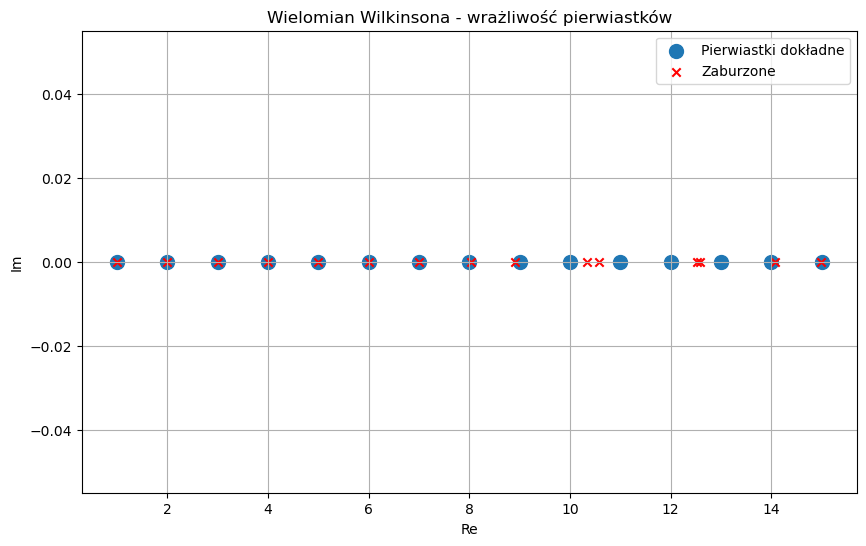

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

p1 = Polynomial([2, 3, 1])
print("Pierwiastki W(x):", p1.roots())

roots_exact = np.arange(1, 16)
p2 = Polynomial.fromroots(roots_exact)

roots_found = p2.roots()
error = np.max(np.abs(np.sort(roots_exact) - np.sort(roots_found)))
print(f"Maksymalny błąd wyznaczonych pierwiastków: {error:.2e}")

coeffs = p2.coef.copy()
coeffs[12] += 1e-5  
p3 = Polynomial(coeffs)
roots_perturbed = p3.roots()

plt.figure(figsize=(10, 6))
plt.scatter(roots_exact.real, roots_exact.imag, label='Pierwiastki dokładne', marker='o', s=100)
plt.scatter(roots_perturbed.real, roots_perturbed.imag, label='Zaburzone', marker='x', color='red')
plt.title('Wielomian Wilkinsona - wrażliwość pierwiastków')
plt.xlabel('Re')
plt.ylabel('Im')
plt.legend()
plt.grid(True)
plt.show()

#Zadanie poszukiwania pierwiastków wielomianów wyższych rzędów bywa źle uwarunkowane. Nawet małę zaburzenie jednego współczynnika sprawia, że część pierwiastków z rzeczywistych staje się zespolona, a ich wartości drastycznie odbiegają od prawidłowych.

***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

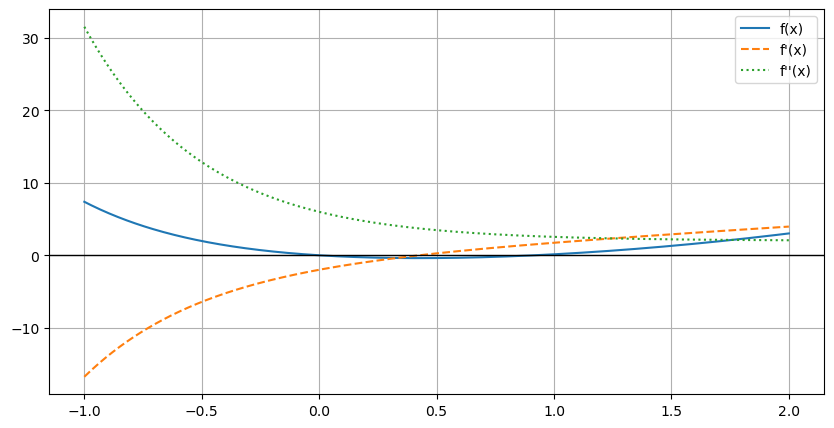

In [2]:
x = np.linspace(-1, 2, 400)
def f(x): return np.exp(-2*x) + x**2 - 1
def df(x): return -2*np.exp(-2*x) + 2*x
def ddf(x): return 4*np.exp(-2*x) + 2

plt.figure(figsize=(10, 5))
plt.plot(x, f(x), label='f(x)')
plt.plot(x, df(x), label="f'(x)", linestyle='--')
plt.plot(x, ddf(x), label="f''(x)", linestyle=':')
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.grid()
plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [5]:
import numpy as np

def bisekcja(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) > 0:
        return None, 0
    
    for i in range(max_iter):
        c = (a + b) / 2.0
        if abs(f(c)) < tol or (b - a) / 2.0 < tol:
            return c, i + 1
        
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
            
    return (a + b) / 2.0, max_iter

def newton(f, df, x0, tol=1e-6, max_iter=100):
    x_prev = x0
    for i in range(max_iter):
        fx = f(x_prev)
        dfx = df(x_prev)
        
        if dfx == 0:
            print("Pochodna równa zero, przerywam.")
            return x_prev, i + 1
            
        x_next = x_prev - fx / dfx
        
        if abs(x_next - x_prev) < tol or abs(f(x_next)) < tol:
            return x_next, i + 1
            
        x_prev = x_next
        
    return x_prev, max_iter

def sieczne(f, x0, x1, tol=1e-6, max_iter=100):
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        
        if fx1 - fx0 == 0:
            print("Dzielenie przez zero, przerywam.")
            return x1, i + 1
            
        x_next = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        
        if abs(x_next - x1) < tol or abs(f(x_next)) < tol:
            return x_next, i + 1
            
        x0 = x1
        x1 = x_next
        
    return x1, max_iter

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [6]:

def f(x): return np.exp(-2*x) + x**2 - 1
def df(x): return -2*np.exp(-2*x) + 2*x

eps = 1e-6

print("--- PIERWSZE MIEJSCE ZEROWE (okolice 0) ---")
print("Bisekcja [-0.5, 0.5]:", bisekcja(f, -0.5, 0.5, tol=eps))
print("Newton (x0 = 0.2):   ", newton(f, df, 0.2, tol=eps))
print("Sieczne (-0.5, 0.2): ", sieczne(f, -0.5, 0.2, tol=eps))

print("\n--- DRUGIE MIEJSCE ZEROWE (okolice 0.9) ---")
print("Bisekcja [0.5, 1.5]:", bisekcja(f, 0.5, 1.5, tol=eps))
print("Newton (x0 = 1.0):   ", newton(f, df, 1.0, tol=eps))
print("Sieczne (0.5, 1.5):  ", sieczne(f, 0.5, 1.5, tol=eps))

--- PIERWSZE MIEJSCE ZEROWE (okolice 0) ---
Bisekcja [-0.5, 0.5]: (0.0, 1)
Newton (x0 = 0.2):    (np.float64(-1.333268894856748e-07), 4)
Sieczne (-0.5, 0.2):  (np.float64(8.068171353359092e-09), 6)

--- DRUGIE MIEJSCE ZEROWE (okolice 0.9) ---
Bisekcja [0.5, 1.5]: (0.9165630340576172, 19)
Newton (x0 = 1.0):    (np.float64(0.916562583572737), 3)
Sieczne (0.5, 1.5):   (np.float64(0.9165625954293092), 6)


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

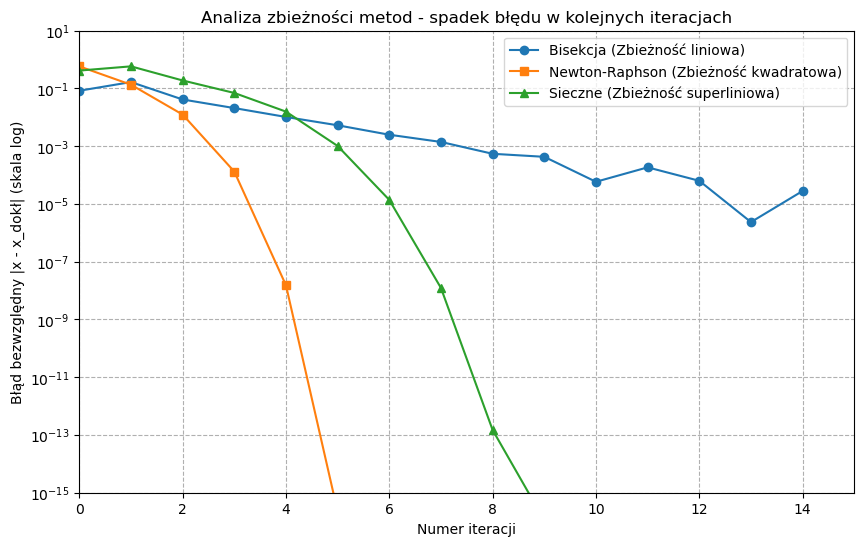

In [ ]:
import matplotlib.pyplot as plt

def newton_history(f, df, x0, max_iter=20):
    hist = [x0]
    for i in range(max_iter):
        dfx = df(hist[-1])
        if dfx == 0 or abs(f(hist[-1])) < 1e-15:
            hist.append(hist[-1])
        else:
            x_next = hist[-1] - f(hist[-1]) / dfx
            hist.append(x_next)
    return np.array(hist)

def bisekcja_history(f, a, b, max_iter=20):
    hist = []
    for i in range(max_iter):
        c = (a + b) / 2.0
        hist.append(c)
        if f(a) * f(c) < 0: 
            b = c
        else: 
            a = c
    return np.array(hist)

def sieczne_history(f, x0, x1, max_iter=20):
    hist = [x0, x1]
    for i in range(max_iter):
        f_curr = f(hist[-1])
        f_prev = f(hist[-2])
        
        if f_curr - f_prev == 0:
            hist.append(hist[-1])
        else:
            x_next = hist[-1] - f_curr * (hist[-1] - hist[-2]) / (f_curr - f_prev)
            hist.append(x_next)
    return np.array(hist)

hist_bis = bisekcja_history(f, 0.5, 1.5, max_iter=15)
hist_new = newton_history(f, df, 1.5, max_iter=15)
hist_sie = sieczne_history(f, 0.5, 1.5, max_iter=15)

exact_root, _ = newton(f, df, 1.0, tol=1e-12)

err_bis = np.abs(hist_bis - exact_root)
err_new = np.abs(hist_new - exact_root)
err_sie = np.abs(hist_sie - exact_root)

plt.figure(figsize=(10, 6))
plt.semilogy(err_bis, label='Bisekcja (Zbieżność liniowa)', marker='o')
plt.semilogy(err_new, label='Newton-Raphson (Zbieżność kwadratowa)', marker='s')
plt.semilogy(err_sie, label='Sieczne (Zbieżność superliniowa)', marker='^')

plt.title("Analiza zbieżności metod - spadek błędu w kolejnych iteracjach")
plt.xlabel("Numer iteracji")
plt.ylabel("Błąd bezwzględny |x - x_dokł| (skala log)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.xlim(0, 15)
plt.ylim(1e-15, 10)
plt.show()